Loading Model...

Target Image: NYBD1-A10_250nM_BT549_site1_FITC_Day1.png


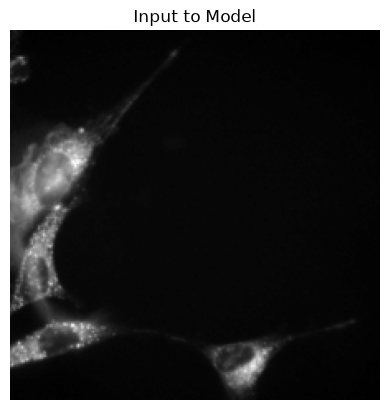

✅ Extraction Complete!
Feature Shape: torch.Size([1, 1024])
First 5 values: [-1.9709668  -2.4357047  -0.16600083 -0.73164105  1.8500603 ]


In [2]:
import torch
from pathlib import Path
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# 모듈화해둔 함수 불러오기
from load_model import get_cell_dino_model

# 1. 모델 로드
print("Loading Model...")
model = get_cell_dino_model()
device = next(model.parameters()).device

# 2. 이미지 딱 1장만 가져오기
data_dir = Path('/workspace/innoDrug/tiff_to_png/data/png_converted')
sample_img_path = next(data_dir.rglob('*.png')) # 폴더 내 첫 번째 PNG 파일
print(f"\nTarget Image: {sample_img_path.name}")

# 3. 전처리 파이프라인 (1채널 흑백)
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# 4. 이미지 전처리 적용
img = Image.open(sample_img_path).convert('L')
img_tensor = transform(img)

# 5. 눈으로 확인 (모델에 들어가기 직전의 모습)
plt.imshow(img_tensor[0], cmap='gray')
plt.title(f"Input to Model")
plt.axis('off')
plt.show()

# 6. 모델 통과 및 특징 벡터 추출
# 배치 차원 추가: [1, 224, 224] -> [1, 1, 224, 224]
img_batch = img_tensor.unsqueeze(0).to(device) 

model.eval()
with torch.no_grad():
    feature = model(img_batch)

print(f"✅ Extraction Complete!")
print(f"Feature Shape: {feature.shape}") 
# 첫 5개의 숫자만 살짝 구경해보기
print(f"First 5 values: {feature[0][:5].cpu().numpy()}")

In [6]:
import torch
import numpy as np
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# 1. 경로 설정
data_dir = Path('/workspace/innoDrug/tiff_to_png/data/png_converted')
save_dir = Path('/workspace/innoDrug/clustering/results')
save_dir.mkdir(parents=True, exist_ok=True)

# 2. 전처리 파이프라인
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

class CellImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.image_paths = list(self.image_dir.rglob('*.png'))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image, str(img_path.relative_to(self.image_dir))

dataset = CellImageDataset(image_dir=data_dir, transform=transform)

# 🏎️ [최적화 1, 2] DataLoader H100 세팅
dataloader = DataLoader(
    dataset, 
    batch_size=512,           # H100 80GB 메모리를 믿고 4배 증가 (OOM 발생 시 256으로 타협)
    shuffle=False, 
    num_workers=0,            # CPU 코어 수에 맞춰 데이터 로딩 일꾼 증가
    pin_memory=True,          # CPU->GPU 데이터 전송 속도 극대화
)

print(f"총 {len(dataset)}장의 이미지 추출 준비 완료 (배치 크기: 512)")

all_features = []
all_filenames = []

model.eval()

# 🏎️ [최적화 4] H100 텐서 코어(bfloat16) 활용 스위치 ON
with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    for images, filenames in tqdm(dataloader):
        # 🏎️ [최적화 3] non_blocking=True 로 비동기 고속 전송
        images = images.to(device, non_blocking=True)
        
        features = model(images)
        
        # bfloat16으로 계산된 결과를 다시 float32로 바꿔서 numpy로 저장 (안전성)
        all_features.append(features.float().cpu().numpy())
        all_filenames.extend(filenames)

# 3. 저장
final_features = np.vstack(all_features) 
np.save(save_dir / 'cell_features.npy', final_features)

with open(save_dir / 'image_filenames.txt', 'w') as f:
    for name in all_filenames:
        f.write(f"{name}\n")

print(f"✅ H100 최적화 추출 완료! Feature 배열 크기: {final_features.shape}")

총 4480장의 이미지 추출 준비 완료 (배치 크기: 512)


100%|██████████| 9/9 [01:12<00:00,  8.10s/it]


✅ H100 최적화 추출 완료! Feature 배열 크기: (4480, 1024)
